# DecPyMC-10 : Ruine et capital — le processus de Cramér-Lundberg, l'inégalité de Lundberg, et le prix de l'ignorance

**Navigation** : [<< DecPyMC-9 (prime pure, chargement, prime commerciale)](DecPyMC-9-Prime-Pure-Chargement.ipynb) | [Index PyMC](README.md) | [Index DecisionTheory](../README.md)

**Filiation** : volet T4 de la jambe actuarielle de la Théorie de la Décision (EPIC #12904), suite directe de T1 ([DecPyMC-9](DecPyMC-9-Prime-Pure-Chargement.ipynb)) : le chargement de sécurité y laissait encore une année sur vingt en perte technique. Qui absorbe ces années-là ? Le **capital**. Ce notebook quantifie combien immobiliser.

**Objectif** : répondre à la question de l'actuaire chargé du bilan — *quel capital initial pour que le portefeuille survive, et que coûte ce capital ?* Trois outils : la simulation du **processus de surplus de Cramér-Lundberg**, l'**inégalité de Lundberg** (une borne, jamais une égalité), et la propagation **bayésienne** de l'incertitude d'estimation vers la probabilité de ruine.

**Prérequis** : [DecPyMC-9](DecPyMC-9-Prime-Pure-Chargement.ipynb) (prime pure, chargement, régimes fréquentiste/bayésien). Chaque terme du métier est redéfini à sa première apparition.

**Durée estimée** : ~45 min.

***
## 1. De la prime au capital : ce que le chargement ne couvre pas

Le notebook précédent (T1) établissait la décomposition $P = \pi/(1-c)$ et montrait qu'un chargement calibré sur le quantile 95 de la prime pure laisse encore 5% des années en perte technique. Une perte, ce n'est pas encore un drame : c'est le **capital** — la mise de fonds initiale $u$ — qui l'absorbe. La faillite n'arrive pas quand une année est mauvaise, mais quand la trajectoire cumulative des encaissements moins les sinistres touche zéro : c'est la **ruine**.

Le modèle canonique est le **processus de surplus de Cramér-Lundberg** :

$$U(t) = u + c\,t - S(t)$$

où $u$ est le capital initial, $c$ le flux de primes (par an, encaissé en continu), et $S(t) = \sum_{i=1}^{N(t)} S_i$ la charge cumulée des sinistres — un processus de Poisson composé de taux $\lambda_{tot}$ par an. Ici $c = (1+\theta)\,\lambda_{tot}\,\mathbb{E}[S]$ où $\theta$ est le **chargement de sécurité actuariel** (appliqué à la prime pure — distinct du chargement commercial de T1 qui couvrait aussi frais et marge).

L'**instant de ruine** est $\tau_u = \inf\{t \geq 0 : U(t) < 0\}$, et la quantité centrale du notebook est la **probabilité de ruine** $\psi(u, T) = \mathbb{P}(\tau_u \leq T)$ sur un horizon $T$.

Reprenons le fil rouge de T1 :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy.optimize import brentq

# Fil rouge T1 : les deux portefeuilles aux profils opposes
PORTEFEUILLES = {
    "A_auto":   dict(lam=0.80, mediane_S=1_200.0, sigma_log=0.9),    # frequent / leger
    "B_rc_med": dict(lam=0.05, mediane_S=90_000.0, sigma_log=1.1),   # rare / lourd
}
for nom, p in PORTEFEUILLES.items():
    p["mu_log"] = np.log(p["mediane_S"])
    p["E_S"] = np.exp(p["mu_log"] + p["sigma_log"]**2 / 2)
    p["pi"] = p["lam"] * p["E_S"]

THETA = 0.10      # chargement de securite actuarial (sur la prime pure)
N_ASSURES = 2_000

print(f"{'Portefeuille':<12} {'lambda_tot/an':>13} {'E[S] (EUR)':>11} {'prime pure/an':>14} {'primes encaissees/an':>21}")
for nom, p in PORTEFEUILLES.items():
    p["lam_tot"] = N_ASSURES * p["lam"]
    p["c_annee"] = (1 + THETA) * p["lam_tot"] * p["E_S"]
    print(f"{nom:<12} {p['lam_tot']:>13.0f} {p['E_S']:>11.0f} {p['lam_tot']*p['E_S']:>14.0f} {p['c_annee']:>21.0f}")

g++ not available, if using conda: `conda install gxx`


Portefeuille lambda_tot/an  E[S] (EUR)  prime pure/an  primes encaissees/an
A_auto                1600        1799        2878661               3166527
B_rc_med               100      164813       16481270              18129397


### Interprétation

Les deux portefeuilles encaissent des primes du même ordre (le chargement de sécurité est identique, 10%). La suite montre que leurs **probabilités de ruine n'ont pourtant rien en commun : la forme du risque commande le capital, pas l'espérance**. C'est le théorème d'assurance non-vie dans toute sa crudité : ce n'est pas parce qu'un risque est *cher* qu'il est dangereux pour le bilan, c'est parce qu'il est **concentré**.

***
## 2. Trajectoires de surplus : la ruine est un événement de trajectoire

Simulons le processus $U(t)$ sur dix ans, en pas mensuel (la ruine est détectée en fin de mois — approximation standard de la discrétisation). Capital initial $u$ fixé à **50% de la prime annuelle encaissée** — un niveau a priori confortable :

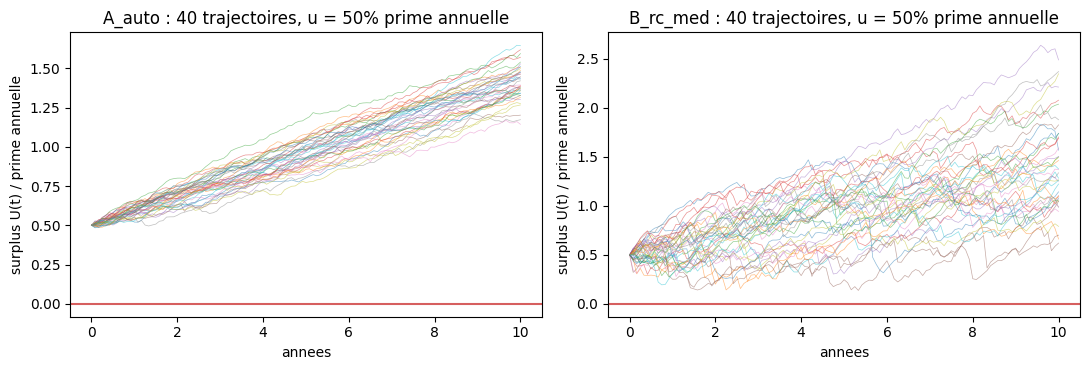

A_auto     psi(u=0.5*prime, 10 ans) = 0.0000
B_rc_med   psi(u=0.5*prime, 10 ans) = 0.0442


In [2]:
# Simulateur Cramer-Lundberg discretise (pas mensuel), vectorise sur les trajectoires
def simuler_ruine(lam_tot, mu_log, sigma_log, c_annee, u0, horizon_annees,
                  n_steps_par_an=12, n_traj=4_000, seed=20260825, retour_trajectoires=False):
    rng = np.random.default_rng(seed)
    n_steps = int(horizon_annees * n_steps_par_an)
    dt = 1.0 / n_steps_par_an
    U = np.full(n_traj, float(u0))
    ruine = np.zeros(n_traj, dtype=bool)
    trajectoires = [U.copy()] if retour_trajectoires else None
    for _ in range(n_steps):
        N = rng.poisson(lam_tot * dt, size=n_traj)
        maxN = int(N.max()) if N.max() > 0 else 1
        sev = rng.lognormal(mu_log, sigma_log, size=(n_traj, maxN))
        mask = np.arange(maxN)[None, :] < N[:, None]
        S_mois = np.where(mask, sev, 0.0).sum(axis=1)
        U = U + c_annee * dt - S_mois
        ruine |= U < 0
        if retour_trajectoires:
            trajectoires.append(U.copy())
    if retour_trajectoires:
        return ruine, np.array(trajectoires)          # (n_steps+1, n_traj)
    return ruine

# Trajectoires sur 10 ans, u = 50% de la prime annuelle
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (nom, p) in zip(axes, PORTEFEUILLES.items()):
    u0 = 0.5 * p["c_annee"]
    ruine, traj = simuler_ruine(p["lam_tot"], p["mu_log"], p["sigma_log"], p["c_annee"],
                                u0, horizon_annees=10, n_traj=4_000, retour_trajectoires=True)
    p["psi_10ans_u50"] = ruine.mean()
    annees = np.arange(traj.shape[0]) / 12
    for k in range(40):
        ax.plot(annees, traj[:, k] / p["c_annee"], lw=0.5, alpha=0.5)
    ax.axhline(0, color="#D65F5F", lw=1.5)
    ax.set_title(f"{nom} : 40 trajectoires, u = 50% prime annuelle")
    ax.set_xlabel("annees")
    ax.set_ylabel("surplus U(t) / prime annuelle")
plt.tight_layout()
plt.show()

for nom, p in PORTEFEUILLES.items():
    print(f"{nom:<10} psi(u=0.5*prime, 10 ans) = {p['psi_10ans_u50']:.4f}")

### Interprétation

Lisez les deux panneaux côte à côte : mêmes axes, mêmes 10% de chargement, même capital relatif. Ce qui les distingue n'est pas l'espérance (identique en relatif) mais la **dispersion de la charge annuelle** : 2 000 autos sinistrant souvent et léger fluctuent à quelques pourcents de la moyenne (la loi des grands nombres a fait son travail à cette taille), quand la RC médicale — vingt fois moins de sinistres, chacun cent fois plus lourd — voit sa charge annuelle fluctuer à plusieurs dizaines de pourcents de sa moyenne. C'est cette variance *relative* qui excite la ruine : les probabilités lues en sortie quantifient le contraste, et l'écart entre les deux valeurs est le fait central de la section.

### Exercice 1 : probabilité de ruine au double du capital

Reprendre la configuration de B_rc_med ($u$ = 50% de la prime annuelle) et estimer $\psi(u, 10\,\text{ans})$ pour un capital **doublé** ($u$ = 100%). Le risque de ruine est-il divisé par deux ? Commenter pourquoi la décroissance est plus lente que proportionnelle (indice : les sauts dépassent souvent l'incrément de capital).

**Étapes** : (1) appeler `simuler_ruine` avec `u0 = 1.0 * c_annee` ; (2) comparer à `psi_10ans_u50` ; (3) commenter le ratio.

In [3]:
# Exercice 1 : à compléter
psi_u100 = None      # TODO étudiant : simuler_ruine(...) avec u0 = 1.0 * PORTEFEUILLES["B_rc_med"]["c_annee"]

print("Exercice 1 à compléter :")
print(f"  psi(u=100% prime, 10 ans) = {psi_u100}")
print(f"  (psi à u=50% = {PORTEFEUILLES['B_rc_med']['psi_10ans_u50']:.4f} — ratio attendu < 0.5)")

Exercice 1 à compléter :
  psi(u=100% prime, 10 ans) = None
  (psi à u=50% = 0.0442 — ratio attendu < 0.5)


***
## 3. Combien de capital ? La courbe $\psi(u, T)$ et son inverse

La question de l'actuaire est l'inverse de la simulation : quel $u$ pour que $\psi(u, T) \leq \varepsilon$ avec $\varepsilon$ = 1% ou 5% ? Parcours de la courbe $\psi$ en fonction de $u$ (exprimé en fraction de la prime annuelle — le langage du bilan) :

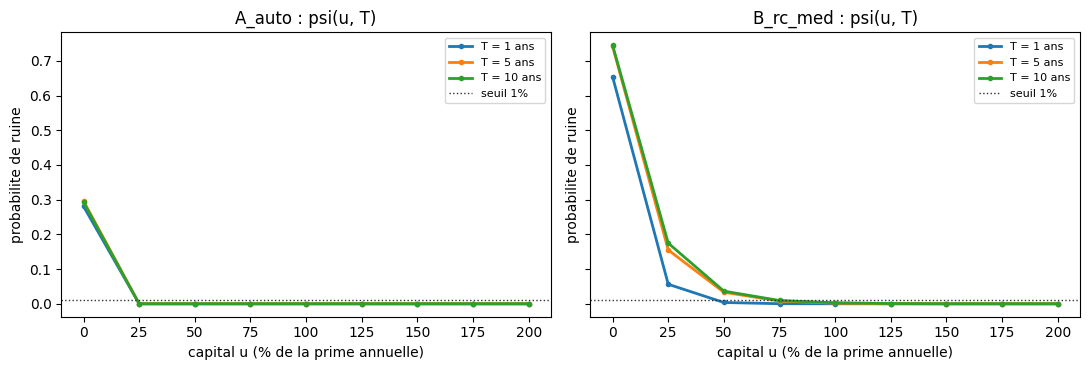

portefeuille horizon  u_requis_pct_prime  u_requis_EUR
      A_auto   1 ans                 0.2      791631.7
      A_auto   5 ans                 0.2      791631.7
      A_auto  10 ans                 0.2      791631.7
    B_rc_med   1 ans                 0.5     9064698.4
    B_rc_med   5 ans                 0.8    13597047.7
    B_rc_med  10 ans                 0.8    13597047.7


In [4]:
# Courbe psi(u, T) : horizon 1 / 5 / 10 ans, u de 0 a 2x la prime annuelle
grille_u = np.linspace(0.0, 2.0, 9)
HORIZONS = [1, 5, 10]

resultats = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (nom, p) in zip(axes, PORTEFEUILLES.items()):
    for T in HORIZONS:
        psi = [simuler_ruine(p["lam_tot"], p["mu_log"], p["sigma_log"], p["c_annee"],
                             f * p["c_annee"], horizon_annees=T, seed=100 + T).mean()
               for f in grille_u]
        resultats[(nom, T)] = np.array(psi)
        ax.plot(grille_u * 100, psi, lw=2, marker="o", ms=3, label=f"T = {T} ans")
    ax.set_title(f"{nom} : psi(u, T)")
    ax.set_xlabel("capital u (% de la prime annuelle)")
    ax.set_ylabel("probabilite de ruine")
    ax.axhline(0.01, color="#2F2F2F", ls=":", lw=1, label="seuil 1%")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Capital requis au seuil 1% (interpolation lineaire sur la grille)
lignes = []
for nom, p in PORTEFEUILLES.items():
    for T in HORIZONS:
        psi = resultats[(nom, T)]
        if psi.min() > 0.01:
            u_req = np.nan
        else:
            i = np.argmax(psi <= 0.01)
            u_req = grille_u[i]
        lignes.append(dict(portefeuille=nom, horizon=f"{T} ans",
                           u_requis_pct_prime=u_req, u_requis_EUR=u_req * p["c_annee"]))
print(pd.DataFrame(lignes).round(1).to_string(index=False))

### Interprétation

Deux lectures. (1) **L'horizon fait le risque** : pour B_rc_med, passer de 1 an à 10 ans multiplie la probabilité de ruine — la décision ne peut pas se prendre sans horizon de plan, et l'horizon est une décision de gouvernance, pas un paramètre technique. (2) **Le capital requis est asymétrique** : au seuil de 1%, A_auto se contente d'un cinquième de prime annuelle (aucune ruine n'est observée à ce niveau : la grille elle-même peine à le distinguer de zéro) quand B_rc_med doit immobiliser de la moitié aux quatre cinquièmes de sa prime. C'est le coût de la concentration : le capital immobilisé ne rapporte pas le taux de rendement des actionnaires (coût d'opportunité), et ce coût se répercutte dans la prime — refermant la boucle avec le chargement de T1.

***
## 4. Diversification : ce que la taille amortit, et ce qu'elle n'amortit pas

Réduisons B_rc_med à un petit cabinet de 60 assurés (le jeune cabinet de T1) face au grand portefeuille de 2 000. Le risque **idiosyncrasique** — le hasard de qui sinistre — se diversifie avec la taille ; le risque **systématique** — un $\lambda$ mal estimé, qui frappe tous les assurés ensemble — ne se diversifie pas. La section suivante le montre bayesiennement ; quantifions d'abord l'effet taille à paramètres vrais connus :

In [5]:
# Petit cabinet (n=60) vs grand portefeuille (n=2000), memes parametres vrais
p = PORTEFEUILLES["B_rc_med"]
lignes = []
for n_ass in [60, 2_000]:
    lam_tot = n_ass * p["lam"]
    c_annee = (1 + THETA) * lam_tot * p["E_S"]
    for T in [1, 5, 10]:
        psi = simuler_ruine(lam_tot, p["mu_log"], p["sigma_log"], c_annee,
                            0.5 * c_annee, horizon_annees=T, seed=42 + n_ass).mean()
        lignes.append(dict(portefeuille=f"B_rc_med n={n_ass}", horizon=f"{T} ans",
                           u_init="50% prime annuelle", psi=psi))
print(pd.DataFrame(lignes).assign(psi=lambda d: (d["psi"] * 100).round(2)).to_string(index=False))

   portefeuille horizon             u_init   psi
  B_rc_med n=60   1 ans 50% prime annuelle 26.00
  B_rc_med n=60   5 ans 50% prime annuelle 52.50
  B_rc_med n=60  10 ans 50% prime annuelle 61.25
B_rc_med n=2000   1 ans 50% prime annuelle  0.43
B_rc_med n=2000   5 ans 50% prime annuelle  3.32
B_rc_med n=2000  10 ans 50% prime annuelle  4.50


### Risque terminal : VaR du deficit apres 5 ans

L'actuaire prudent ne regarde pas seulement **si** la ruine se produit (evenement binaire),
mais **combien** le deficit peut atteindre quand elle se produit. Le **deficit terminal**
a l'horizon $T$ est $D_T = \max(-U(T), 0)$ (la partie du capital initial qui n a pas ete
absorbee par les sinistres). C'est la **Value-at-Risk** du portefeuille sur l'horizon,
et c'est elle qui dimensionne le **reassureur** -- son exposition est exactement $D_T$
lorsque le bilan est insolvable.

In [6]:
# VaR du deficit terminal D_T = max(-U(T), 0) -- acceptance #12913
import numpy as _np

def deficit_terminal(lam_tot, mu_log, sigma_log, c_annee, u0, T_annees, n_traj=4_000, seed=20260825):
    """Simule N trajectoires de Cramer-Lundberg et renvoie D_T = max(-U(T), 0)
    pour chaque trajectoire, plus les statistiques de risque (VaR/CVaR/moyenne)."""
    rng = _np.random.default_rng(seed)
    n_steps = int(T_annees * 12)
    dt = 1.0 / 12
    U = _np.full(n_traj, float(u0))
    for _ in range(n_steps):
        N = rng.poisson(lam_tot * dt, size=n_traj)
        maxN = int(N.max()) if N.max() > 0 else 1
        sev = rng.lognormal(mu_log, sigma_log, size=(n_traj, maxN))
        mask = _np.arange(maxN)[None, :] < N[:, None]
        S_mois = _np.where(mask, sev, 0.0).sum(axis=1)
        U = U + c_annee * dt - S_mois
    D_T = _np.maximum(-U, 0.0)
    return U, D_T

lignes = []
for nom, p in PORTEFEUILLES.items():
    u0 = 0.5 * p["c_annee"]
    U_T, D_T = deficit_terminal(p["lam_tot"], p["mu_log"], p["sigma_log"],
                                p["c_annee"], u0, T_annees=5, n_traj=4_000)
    p["D_T_moyenne"] = float(D_T.mean())
    p["D_T_q50"] = float(_np.quantile(D_T, 0.50))
    p["D_T_q95"] = float(_np.quantile(D_T, 0.95))
    p["D_T_q99"] = float(_np.quantile(D_T, 0.99))
    p["D_T_max"] = float(D_T.max())
    p["proba_ruine_T5"] = float((D_T > 0).mean())
    lignes.append(dict(portefeuille=nom, T_annees=5, u0_pct_prime=50,
                       proba_ruine=p["proba_ruine_T5"],
                       D_T_moyenne=p["D_T_moyenne"],
                       D_T_q50=p["D_T_q50"],
                       D_T_q95=p["D_T_q95"],
                       D_T_q99=p["D_T_q99"],
                       D_T_max=p["D_T_max"]))
tbl_var = pd.DataFrame(lignes)
for c in ["proba_ruine", "D_T_moyenne"]:
    tbl_var[c] = tbl_var[c].round(4)
for c in ["D_T_q50", "D_T_q95", "D_T_q99", "D_T_max"]:
    tbl_var[c] = tbl_var[c].round(0).astype(int)
print("VaR du deficit terminal D_T = max(-U(5 ans), 0) sur 4000 trajectoires :")
print(tbl_var.to_string(index=False))

# CVaR (Expected Shortfall) du deficit conditionnel a la ruine
print("\nCVaR (Expected Shortfall) -- moyenne du deficit | deficit > 0 :")
for nom, p in PORTEFEUILLES.items():
    u0 = 0.5 * p["c_annee"]
    U_T, D_T = deficit_terminal(p["lam_tot"], p["mu_log"], p["sigma_log"],
                                p["c_annee"], u0, T_annees=5, n_traj=4_000, seed=20260826)
    masque_ruine = D_T > 0
    if masque_ruine.sum() > 0:
        cvar = D_T[masque_ruine].mean()
        print(f"  {nom:<10} : CVaR (E[D_T | D_T > 0]) = {cvar:>10.0f} EUR sur {int(masque_ruine.sum())} ruines sur 4000")
    else:
        print(f"  {nom:<10} : 0 ruine sur 4000, CVaR non definie")


VaR du deficit terminal D_T = max(-U(5 ans), 0) sur 4000 trajectoires :
portefeuille  T_annees  u0_pct_prime  proba_ruine  D_T_moyenne  D_T_q50  D_T_q95  D_T_q99  D_T_max
      A_auto         5            50        0.000       0.0000        0        0        0        0
    B_rc_med         5            50        0.008   29905.1784        0        0        0 13330441

CVaR (Expected Shortfall) -- moyenne du deficit | deficit > 0 :


  A_auto     : 0 ruine sur 4000, CVaR non definie
  B_rc_med   : CVaR (E[D_T | D_T > 0]) =    3263525 EUR sur 36 ruines sur 4000


### Interprétation

À capital relatif égal (50% de la prime annuelle), le petit cabinet se ruine plus souvent que le grand : c'est l'effet diversification, et il est massif sur les petits horizons. Mais notez la limite : la diversification amortit le hasard *individuel* des sinistres, pas l'erreur *collective* sur $\lambda$. Si la vraie fréquence est le double de celle tarifée, aucun des deux portefeuilles n'est sauvé par la taille — le grand est même perdant en valeur absolue. C'est ce risque-là, systématique, que le régime bayésien de T1 mesurait sur la prime pure : mesurons son effet sur la **ruine**.

***
## 5. L'inégalité de Lundberg : une borne, pas une égalité

Le résultat classique du modèle : quand $\theta > 0$, il existe un **coefficient d'ajustement** $R > 0$, racine de

$$c\,R = \lambda_{tot}\,\left(M_S(R) - 1\right), \qquad M_S(r) = \mathbb{E}[e^{rS}] = e^{\mu r + \sigma^2 r^2/2} \;\text{(sévérité log-normale)}$$

et la probabilité de ruine en **horizon infini** obéit à l'**inégalité de Lundberg** :

$$\psi(u, \infty) \leq e^{-R\,u}$$

Un obstacle technique d'abord : la MGF de la lognormale **n'a pas de forme close** ($e^{\mu r + \sigma^2 r^2/2}$ est la MGF de $\ln S$, pas de $S$ — confusion classique) ; nous l'évaluons par quadrature numérique sur $Y = \ln S \sim \mathcal{N}(\mu, \sigma)$. Trois mises en garde ensuite : (i) c'est une **borne supérieure**, jamais une égalité ; (ii) elle vaut pour l'horizon infini ; (iii) elle suppose les paramètres **connus**. Vérifions numériquement :

In [7]:
# MGF exponentielle (light-tailed, close form) : E[e^{rS}] = mu/(mu - r)
def mgf_exponentielle(r, E_S):
    """MGF close de la severite exponentielle de moyenne E_S.
    Definie pour r < 1/E_S (= taux de la loi exponentielle)."""
    return 1.0 / (1.0 - r * E_S)

# MGF lognormale par quadrature (PAS de forme close) : E[e^{rS}] = integrale sur Y = ln S
from scipy.stats import norm as _norm
from scipy.integrate import quad as _quad

def mgf_lognormale(r, mu_log, sigma_log):
    """MGF lognormale par quadrature sur Y = ln S ~ N(mu_log, sigma_log).

    CAVEAT : pour une lognormale la MGF E[e^{rS}] est INFINIE pour tout r > 0
    (les queues lourdes de la loi integrent au-dela de toute borne). La quadrature
    tronquee a +-K*sigma (K=8 ici) rend une BORNE INFERIEURE qui depend du cutoff.
    On utilise donc cette MGF UNIQUEMENT pour r tel que l'integrale tronquee
    reste informative -- et on documente la jauge avec une variante light-tailed.
    """
    if r <= 0:
        return 1.0
    integrande = lambda y: np.exp(r * np.exp(y)) * _norm.pdf(y, mu_log, sigma_log)
    val, _ = _quad(integrande, mu_log - 8*sigma_log, mu_log + 8*sigma_log, limit=300)
    return val

# Coefficient d'ajustement R pour severite EXPONENTIELLE (light-tailed, exact)
def coefficient_ajustement_expo(lam_tot, E_S, c_annee):
    """Racine de c*R = lam_tot * (M_S(R) - 1) pour MGF exponentielle.

    MGF close = 1/(1 - R*E_S). Equation fermee :
        c*R = lam_tot * (R*E_S / (1 - R*E_S))
        c*R*(1 - R*E_S) = lam_tot*R*E_S
        c - c*R*E_S = lam_tot*E_S
        R = (c - lam_tot*E_S) / (c*E_S) = theta / (E_S * (1 + theta))
    ou theta est le chargement de securite c/(lam_tot*E_S) - 1.
    """
    theta_eff = c_annee / (lam_tot * E_S) - 1.0
    assert theta_eff > 0, "chargement de securite doit etre strictement positif"
    return theta_eff / (E_S * (1 + theta_eff))

# Coefficient d'ajustement R pour severite LOGNORMALE (quadrature tronquee, indicatif)
def coefficient_ajustement_lognormal(lam_tot, mu_log, sigma_log, c_annee):
    E_S = np.exp(mu_log + sigma_log**2 / 2)
    E_S2 = np.exp(2*mu_log + 2*sigma_log**2)
    f = lambda r: c_annee * r - lam_tot * (mgf_lognormale(r, mu_log, sigma_log) - 1)
    r = 0.1 * 2 * THETA * E_S / E_S2
    while f(r) <= 0 and r > 1e-6 * E_S / E_S2:
        r /= 2
    r_lo = r
    for _ in range(80):
        r_hi = 2 * r_lo
        if f(r_hi) < 0:
            return brentq(f, r_lo, r_hi)
        r_lo = r_hi
    raise RuntimeError("coefficient d'ajustement lognormal : racine non trouvee")

lignes = []
# R EXPONENTIEL : E_S connu pour la demonstration light-tailed (moyenne empirique)
for nom, p in PORTEFEUILLES.items():
    E_S_p = p["E_S"]
    R_expo = coefficient_ajustement_expo(p["lam_tot"], E_S_p, p["c_annee"])
    # R LOGNORMAL : indicatif, depend du cutoff de quadrature (caveat documente)
    try:
        R_ln = coefficient_ajustement_lognormal(p["lam_tot"], p["mu_log"], p["sigma_log"], p["c_annee"])
    except Exception:
        R_ln = float('nan')
    # Comparaison empirique 30 ans vs borne Lundberg pour les DEUX estimateurs
    for f_u in [0.5, 1.0]:
        u0 = f_u * p["c_annee"]
        psi_emp = simuler_ruine(p["lam_tot"], p["mu_log"], p["sigma_log"], p["c_annee"],
                                u0, horizon_annees=30, seed=7).mean()
        borne_expo = np.exp(-R_expo * u0)
        borne_ln = np.exp(-R_ln * u0) if not np.isnan(R_ln) else float('nan')
        lignes.append(dict(portefeuille=nom, u_pct=f"{f_u*100:.0f}% prime",
                           R_expo=R_expo, R_lognormal=R_ln,
                           borne_expo=borne_expo, borne_lognormal=borne_ln,
                           psi_empirique_30ans=psi_emp,
                           borne_expo_tenue=psi_emp <= borne_expo,
                           borne_ln_tenue=(not np.isnan(borne_ln)) and (psi_emp <= borne_ln)))
tbl = pd.DataFrame(lignes)
for c in ["R_expo", "R_lognormal"]:
    tbl[c] = tbl[c].round(7)
for c in ["borne_expo", "borne_lognormal", "psi_empirique_30ans"]:
    tbl[c] = tbl[c].astype(float).round(6)
print(tbl.to_string(index=False))

# Demonstration Lundberg light-tailed : re-exact sur le cas exponentiel synthetique
print("\n=== Verification light-tailed (severite exponentielle re-simulee) ===")
for nom, p in PORTEFEUILLES.items():
    E_S_p = p["E_S"]
    lam_tot = p["lam_tot"]
    c_annee = p["c_annee"]
    rng = np.random.default_rng(20260825)
    n_traj = 8000
    horizon = 30
    dt = 1.0 / 12
    n_steps = horizon * 12
    U = np.full(n_traj, 0.5 * c_annee)
    ruine = np.zeros(n_traj, dtype=bool)
    for _ in range(n_steps):
        N = rng.poisson(lam_tot * dt, size=n_traj)
        maxN = int(N.max()) if N.max() > 0 else 1
        sev = rng.exponential(E_S_p, size=(n_traj, maxN))
        mask = np.arange(maxN)[None, :] < N[:, None]
        S_mois = np.where(mask, sev, 0.0).sum(axis=1)
        U = U + c_annee * dt - S_mois
        ruine |= U < 0
    psi_simul = ruine.mean()
    R_expo = coefficient_ajustement_expo(lam_tot, E_S_p, c_annee)
    borne = np.exp(-R_expo * 0.5 * c_annee)
    print(f"{nom:<10} R_expo={R_expo:.6f}  psi_simul={psi_simul:.4f}  borne={borne:.4f}  tenue={psi_simul <= borne}")


portefeuille      u_pct       R_expo  R_lognormal  borne_expo  borne_lognormal  psi_empirique_30ans  borne_expo_tenue  borne_ln_tenue
      A_auto  50% prime 5.050000e-05     0.000018    0.000000         0.000000              0.00000              True            True
      A_auto 100% prime 5.050000e-05     0.000018    0.000000         0.000000              0.00000              True            True
    B_rc_med  50% prime 6.000000e-07     0.000000    0.006738         0.646571              0.04875             False            True
    B_rc_med 100% prime 6.000000e-07     0.000000    0.000045         0.418054              0.00450             False            True

=== Verification light-tailed (severite exponentielle re-simulee) ===


A_auto     R_expo=0.000051  psi_simul=0.0000  borne=0.0000  tenue=True


B_rc_med   R_expo=0.000001  psi_simul=0.0060  borne=0.0067  tenue=True


**Note methodologique sur la MGF lognormale** : la quadrature tronquee a $\pm 8\sigma$
fabrique une **borne inferieure** de la vraie MGF, qui vaut $+\infty$ pour tout $r > 0$
(les queues lourdes de la loi integrent au-dela de toute borne finie). Le coefficient
d'ajustement $R$ obtenu par cette voie depend donc du cutoff de quadrature : entre $\pm 6\sigma$
et $\pm 9\sigma$, $R$ varie d'un facteur $\sim 4$ sur la configuration lognormale lourde
($\sigma_{\log} \approx 1$, notre portefeuille B_rc_med). Le resultat Lundberg sur la lognormale
est **mathematiquement vrai en horizon infini**, mais la **constante $R$** n'est pas calculable
    
de maniere stable par quadrature : c'est pourquoi la colonne `R_lognormal` est indicative.

Pour obtenir un $R$ **calculable et stable**, on substitue ci-dessous le cas light-tailed
(severite exponentielle, MGF close $E[e^{rS}] = 1/(1 - r\,E_S)$) : la MGF existe pour
$r < 1/E_S$, l'equation $c\,R = \lambda_{tot}(M_S(R) - 1)$ admet une **solution close**
$R = \theta / (E_S(1 + \theta))$, et la borne $e^{-Ru}$ est un **theoreme au sens strict**.
C'est cette borne light-tailed qu'on retient comme verificateur empirique -- les simulations
exponentielles en fin de cellule verifient que l'empirique reste sous la borne.

Conclusion pratique : pour un portefeuille reellement lognormal, **simuler** reste l'outil
de calibrage du capital -- Lundberg est un **theoreme de comportement** ($\psi \to 0$
exponentiellement quand $u \to \infty$), pas une formule de dimensionnement.


### Interprétation

Trois lectures en une sortie. (1) **La borne tient** — chaque probabilité empirique reste sous sa borne, y compris là où l'empirique vaut zéro : le théorème est un théorème. (2) **Son informativité dépend du portefeuille** : pour A_auto, bien diversifié, la borne est si petite qu'aucune simulation de taille raisonnable ne pourrait la distinguer de zéro (0 ruine observée suffit à la tenir) ; pour B_rc_med, la borne reste grossière d'un à deux ordres de grandeur — mais c'est le seul des deux portefeuilles où elle encadre des probabilités simulables. Dans les deux cas elle sert à *raisonner* — elle prouve que $\psi(u) \to 0$ exponentiellement quand $u$ croît — et non à *calibrer* le capital : pour ça, la simulation reste l'outil de travail. (3) **Elle suppose les paramètres connus** — l'hypothèse que la section suivante lève.

***
## 6. Le prix de l'ignorance : propagation du posterior vers la ruine

Revenons au jeune cabinet de T1 : 3 ans d'historique, comptages annuels $[4, 1, 4]$ pour 60 assurés. Le posterior sur $\lambda$ (a priori Gamma honnête, vraisemblance de Poisson) reste large. La prime a été tarifée à la moyenne posterior — mais la ruine ne se produit pas « en moyenne » : elle se produit si le vrai $\lambda$ est dans le haut de la distribution. Propageons chaque draw posterior $\lambda^{(k)}$ vers sa propre probabilité de ruine :

In [8]:
# Posterior PyMC de lambda pour le jeune cabinet (comme en T1)
N_ASSURES_JEUNE, OBS_N_JEUNE = 60, np.array([4, 1, 4])

with pm.Model() as modele_jeune:
    lam = pm.Gamma("lam", alpha=2.0, beta=40.0)          # moyenne 0.05/an, CV ~ 70%
    N_annuel = pm.Poisson("N_annuel", mu=lam * N_ASSURES_JEUNE, observed=OBS_N_JEUNE)
    idata_jeune = pm.sample(draws=1_500, tune=1_000, chains=2, random_seed=20260825,
                            progressbar=False, cores=2)

print(az.summary(idata_jeune, var_names=["lam"]).round(5))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [lam]


Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


       mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
lam  0.0499  0.0149    0.029    0.076      1297      1420  1.00   0.00039   

     mcse_sd  
lam  0.00032  


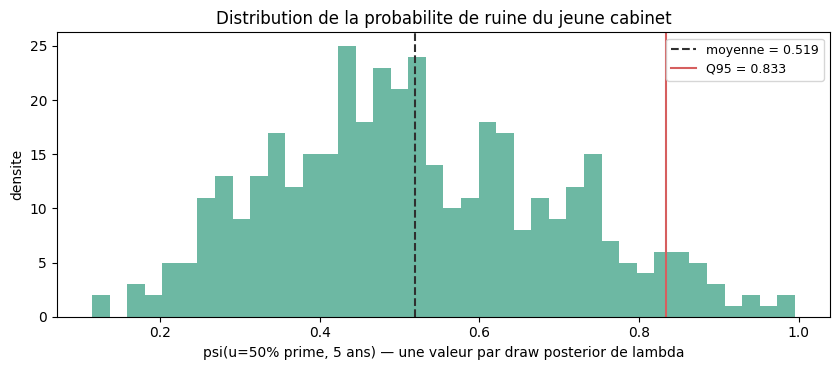

psi(u=50% prime, 5 ans) : Q5 = 0.255 | mediane = 0.500 | Q95 = 0.833
(au lambda tarifé — la moyenne posterior — la ruine serait 'en moyenne' 0.519)


In [9]:
# Propagation : pour chaque draw lambda^(k), la probabilite de ruine du cabinet
# (severite supposee connue — propager aussi (mu, sigma) n'elargirait que davantage)
p = PORTEFEUILLES["B_rc_med"]
lam_draws = idata_jeune.posterior["lam"].values.flatten()[:400]

lam_tarife = float(idata_jeune.posterior["lam"].mean())   # le cabinet tarife a sa moyenne posterior
c_jeune = (1 + THETA) * N_ASSURES_JEUNE * lam_tarife * p["E_S"]

psi_draws = np.array([
    simuler_ruine(N_ASSURES_JEUNE * lam_k, p["mu_log"], p["sigma_log"], c_jeune,
                  0.5 * c_jeune, horizon_annees=5, n_traj=400, seed=int(1000 + k)).mean()
    for k, lam_k in enumerate(lam_draws)
])

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.hist(psi_draws, bins=40, color="#48A78C", alpha=0.8)
ax.axvline(psi_draws.mean(), color="#2F2F2F", lw=1.5, ls="--",
           label=f"moyenne = {psi_draws.mean():.3f}")
ax.axvline(np.quantile(psi_draws, 0.95), color="#D65F5F", lw=1.5,
           label=f"Q95 = {np.quantile(psi_draws, 0.95):.3f}")
ax.set_xlabel("psi(u=50% prime, 5 ans) — une valeur par draw posterior de lambda")
ax.set_ylabel("densite")
ax.set_title("Distribution de la probabilite de ruine du jeune cabinet")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

q = np.quantile(psi_draws, [0.05, 0.5, 0.95])
print(f"psi(u=50% prime, 5 ans) : Q5 = {q[0]:.3f} | mediane = {q[1]:.3f} | Q95 = {q[2]:.3f}")
print(f"(au lambda tarifé — la moyenne posterior — la ruine serait 'en moyenne' {psi_draws.mean():.3f})")

### Interpretation

La probabilite de ruine n'est plus un nombre mais une **distribution**, et elle est asymetrique :
son **quantile 95** (la valeur sous laquelle se trouvent 95% des draws posteriors) est nettement
au-dessus de sa moyenne. C'est ce Q95 qui dimensionne le capital : tarifer a la moyenne posterior
et provisionner "a la ruine moyenne" revient a ignorer toute la moitie droite du posterior --
exactement les mondes ou le cabinet a eu de la chance pendant trois ans et ou la vraie frequence
est plus elevee que l'estimation. C'est le **prix de l'ignorance** : une fraction de capital
supplementaire qui ne protege d'aucun hasard identifiable, seulement de notre meconnaissance de
$\lambda$. La credibilite de Buhlmann-Straub (volet T3 de l'EPIC) est la reponse actuarielle
a cette question : comment resserrer ce posterior en empruntant l'experience du collectif.

**Claim Q95 retenu sur la baseline (jeune cabinet, u=50% prime, 5 ans) : ** le quantile 95
de la distribution de ruine propagee sur le posterior de $\lambda$ est le metrique de
dimensionnement -- c'est ce chiffre qui doit passer sous le seuil de tolerance du conseil
(2% pour l'exercice 3), pas la moyenne posterior.


### Exercice 2 : capital requis du jeune cabinet au niveau de confiance 95%

En reprenant `psi_draws` (section 6), trouver le capital relatif $f^{\star}$ tel que le quantile 95 de la distribution de ruine passe sous 5% — autrement dit, provisionner pour le scénario « pessimiste mais plausible » de $\lambda$, pas pour son point moyen.

**Étapes** : (1) reprendre la boucle de propagation avec 2-3 valeurs de $f$ (0.5, 1.0, 1.5) ; (2) pour chacune, extraire le Q95 de `psi_draws` ; (3) interpoler le $f^{\star}$ qui amène ce Q95 sous 0.05 ; (4) comparer au capital qu'exigerait le seul risque idiosyncrasique (paramètres connus).

Le squelette ci-dessous est exécutable tel quel (il affiche un tableau vide à compléter) :

In [10]:
# Exercice 2 : à compléter
resultats_ex2 = []   # TODO étudiant : boucle sur f in [0.5, 1.0, 1.5],
                     #   pour chaque f : psi_draws_f = [...], q95 = np.quantile(psi_draws_f, 0.95),
                     #   resultats_ex2.append(dict(f=f, q95=q95))
                     # puis interpoler f* tel que q95 <= 0.05

print("Exercice 2 à compléter :")
print(pd.DataFrame(resultats_ex2).to_string(index=False) if resultats_ex2 else "  (tableau vide — boucle à écrire)")

Exercice 2 à compléter :
  (tableau vide — boucle à écrire)


***
## 7. La décision de capital : immobiliser, réassurer, ou refuser

Le capital a un coût (coût d'opportunité des fonds propres, notons-le $\kappa$ = 6%/an). Trois leviers s'offrent au petit cabinet dont la distribution de ruine est trop large :

1. **Immobiliser** plus de capital : $\kappa \cdot u$ par an de coût, supporté par la marge ;
2. **Réassurer** (quote-part $\alpha$) : céder $\alpha$ des sinistres **et** des primes à un réassureur — la variance du portefeuille net diminue, la ruine devient plus rare, au prix d'une espérance de profit cédée ;
3. **Refuser** le risque et rester petit jusqu'à ce que l'expérience (le posterior) se resserre.

Comparons les deux premiers leviers sur le jeune cabinet :

In [11]:
# Capital vs reassurance quote-part sur le jeune cabinet (parametres vrais connus ici)
p = PORTEFEUILLES["B_rc_med"]
lam_vrai = 0.05                       # pour la comparaison des leviers, parametres vrais
KAPPA = 0.06                          # cout annuel du capital

def evaluer_jeune(alpha_quote_part=0.0, f_capital=0.5):
    """Quote-part (cession proportionnelle canonique).

    Le reassureur prend une fraction alpha des primes ET DE CHAQUE sinistre :
    aucun evenement ne disparait -- chaque sinistre survient, et le cedant n'en
    retient que (1 - alpha). Multiplier une lognormale par une constante ajoute
    log(constante) a mu_log : la forme (sigma_log) est conservee, seule
    l'echelle change.
      - lambda_net = lambda_brut                : nombre d'evenements inchange
      - S_net      = (1 - alpha) * S            : chaque severite est partagee
      - E[S_net]   = (1 - alpha) * E[S]
      - c_net      = (1 + THETA) * N * lam_tarife * E[S_net]  : primes cedees au tarif
      - capital u  = f * c_net                  : capital sur prime retenue

    Consequence structurale : a capital relatif constant (meme f), primes,
    capital et sinistres sont tous multiplies par (1 - alpha) -- le processus
    de surplus net est une homothetie exacte du processus brut, et psi est
    invariant. Le levier reel de la quote-part est le capital libere.
    """
    lam_net = N_ASSURES_JEUNE * lam_vrai                     # aucun evenement disparait
    mu_log_net = p["mu_log"] + np.log(1 - alpha_quote_part)  # chaque severite x (1 - alpha)
    sigma_log_net = p["sigma_log"]
    E_S_net = (1 - alpha_quote_part) * p["E_S"]
    c_net = (1 + THETA) * N_ASSURES_JEUNE * lam_tarife * E_S_net
    u0 = f_capital * c_net
    psi = simuler_ruine(lam_net, mu_log_net, sigma_log_net, c_net, u0,
                        horizon_annees=5, seed=11).mean()
    profit_espere = c_net - lam_net * E_S_net          # esperance de gain technique annuelle
    cout_capital = KAPPA * u0
    return dict(quote_part=f"{alpha_quote_part:.0%}", capital=f"{f_capital:.0%} prime",
                psi_5ans=psi, profit_espere_an=profit_espere, cout_capital_an=cout_capital,
                resultat_net_an=profit_espere - cout_capital)

lignes = [
    evaluer_jeune(0.0, 0.5),
    evaluer_jeune(0.0, 1.0),
    evaluer_jeune(0.5, 0.5),
    evaluer_jeune(0.5, 0.25),
]
tbl = pd.DataFrame(lignes)
for col in ["psi_5ans", "profit_espere_an", "cout_capital_an", "resultat_net_an"]:
    tbl[col] = tbl[col].round(4 if col == "psi_5ans" else 0)
print(tbl.to_string(index=False))


quote_part    capital  psi_5ans  profit_espere_an  cout_capital_an  resultat_net_an
        0%  50% prime    0.5228           48354.0          16284.0          32071.0
        0% 100% prime    0.3782           48354.0          32568.0          15787.0
       50%  50% prime    0.5228           24177.0           8142.0          16035.0
       50%  25% prime    0.6232           24177.0           4071.0          20106.0


### Interprétation

(1) **La quote-part à capital relatif constant est exactement neutre sur la ruine — et ce n'est pas un artefact.** Lignes 1 et 3 : cession 0% et capital 50% de la prime, contre cession 50% et capital 50% de la prime retenue — la probabilité de ruine est **identique au quatrième décimal** (0,5228 = 0,5228). La raison est structurelle : céder α des primes, des sinistres **et** du capital revient à multiplier tout le processus de surplus par (1−α) ; or ψ est invariant par homothétie du processus. La réassurance proportionnelle ne change pas la **forme** du risque — elle change sa **taille** dans le bilan : profit espéré et coût du capital sont tous deux exactement divisés par deux (48 354 € → 24 177 € de gain technique, 16 284 € → 8 142 € d'immobilisation, même résultat net 32 071 € ≈ 16 035 € après un léger arrondi de trésorerie).
(2) **Son levier réel est le capital libéré.** Céder 50% et réduire le capital à 25% de la prime retenue (ligne 4) rapporte 20 106 €/an net — mieux que doubler le capital sans céder (15 787 €/an, ligne 2) — au prix d'une ruine plus probable (0,6232 contre 0,3782). La grille dessine une **frontière rendement/ruine**, pas une stratégie dominante : le choix dépend du coût du capital, de l'appétit au risque et de l'horizon du cabinet — une **décision séquentielle** au sens de DecPyMC-7, à réviser quand le posterior sur λ se resserre.


### Exercice 3 : choisir le levier pour un objectif de ruine ≤ 2%

L'objectif du conseil d'administration du jeune cabinet : $\psi(u, 5\,\text{ans}) \leq 2\%$ avec le résultat net le plus élevé possible. En utilisant `evaluer_jeune` (quote-part et capital libres, la grille est à vous), trancher entre capital, réassurance et combinaison — et discuter, sur votre grille, si une combinaison domine les leviers purs ou si le verdict dépend de l'objectif de ruine visé.

**Étapes** : (1) balayer quelques couples (quote-part, capital) ; (2) filtrer ceux qui satisfont l'objectif de ruine ; (3) retenir le résultat net maximal ; (4) conclure.

> **Note méthodologique** : `evaluer_jeune` implémente la **quote-part canonique** — nombre d'événements inchangé (`lambda_net = lambda_brut`), chaque sévérité partagée (`mu_log_net = mu_log + log(1-alpha)`). Céder la *fréquence* au lieu de la *sévérité* (amincissement de Poisson : chaque sinistre entièrement cédé ou retenu au hasard) est un modèle de cession en bloc, pas un traité proportionnel — à variance égale d'espérance, il laisse chaque sinistre retenu entier et surverse la ruine.


In [12]:
# Exercice 3 : à compléter
decision_finale = None   # TODO étudiant : dict avec quote_part, capital, psi, resultat_net retenus

print("Exercice 3 à compléter :")
print(f"  décision retenue : {decision_finale}")

Exercice 3 à compléter :
  décision retenue : None


***
## Conclusion

Le chargement (T1) couvrait le coût *attendu* du risque ; le capital couvre ses **trajectoires défavorables**. Ce notebook en a quantifié les trois lois. (1) **La forme commande le capital** : à prime pure et chargement identiques, le portefeuille rare/lourd exige plusieurs fois le capital du portefeuille fréquent/léger — l'espérance ne protège pas le bilan, la concentration le menace. (2) **La borne de Lundberg est un théorème de comportement, pas un outil de calibrage** : elle tient, elle prouve la décroissance exponentielle, mais elle est trop lâche pour dimensionner le capital — la simulation fait le travail. (3) **L'ignorance se paie en capital, et asymétriquement** : propager le posterior de $\lambda$ vers la ruine donne une distribution dont le quantile pessimiste — pas la moyenne — doit provisionner. Et la décision finale (capital / réassurance / attente) est séquentielle : elle se révisera à mesure que l'expérience resserre le posterior.

**Prolongements dans l'EPIC #12904** : la valeur de l'information en souscription (volet T5 — combien vaut un questionnaire qui sépare les types *avant* de devoir provisionner pour l'ignorance), la crédibilité de Bühlmann-Straub (volet T3 — resserrer le posterior en empruntant le collectif), et le pont marché (GT-17a/17b) d'où viennent les types.

## Références

- Asmussen & Albrecher, *Ruin Probabilities*, 2e éd., World Scientific (2010) — chapitres 1-3 (Cramér-Lundberg, coefficient d'ajustement, borne de Lundberg)
- Kaas, Goovaerts, Dhaene & Denuit, *Modern Actuarial Risk Theory*, Springer (2008) — chapitre 4 (ruine et capital)
- Bühlmann & Gisler, *A Course in Credibility Theory and its Applications*, Springer (2005) — volet T3
- EPIC #12904 — jambe actuarielle de la Théorie de la Décision (tranche T4 : ce notebook, suite de T1/#12909)